# 1. Install libraries (if needed)

In [29]:
!pip install torch transformers tqdm pandas scikit-learn matplotlib

# 2. Import the library & inspect defaults

In [30]:
import simple_bert_fake_reviews as sbr

print("Default MODEL_NAME:   ", sbr.MODEL_NAME)
print("Default MAX_LEN:      ", sbr.MAX_LEN)
print("Default BATCH_SIZE:   ", sbr.BATCH_SIZE)
print("Default LEARNING_RATE:", sbr.LEARNING_RATE)

Default MODEL_NAME:    distilbert-base-uncased
Default MAX_LEN:       128
Default BATCH_SIZE:    16
Default LEARNING_RATE: 3e-05


## 2.1 Change hyperparameters

In [31]:
# Students can edit these and rerun the training.
sbr.MODEL_NAME = "bert-base-uncased"   # or "distilbert-base-uncased"
sbr.MAX_LEN = 128                      # try 64 or 256
sbr.BATCH_SIZE = 16                    # try 8 or 32
sbr.LEARNING_RATE = 2e-5               # try 5e-5, 1e-5, etc.

print("Now using:")
print("MODEL_NAME   =", sbr.MODEL_NAME)
print("MAX_LEN      =", sbr.MAX_LEN)
print("BATCH_SIZE   =", sbr.BATCH_SIZE)
print("LEARNING_RATE=", sbr.LEARNING_RATE)

Now using:
MODEL_NAME   = bert-base-uncased
MAX_LEN      = 128
BATCH_SIZE   = 16
LEARNING_RATE= 2e-05


# 3. Select device

In [32]:
device = sbr.get_device()
device

device(type='cuda')

# 4. Load dataset

In [33]:
csv_path = "CellPhonesAccessoriesdeceptivetruthful_dataset.txt"  # <-- your file

TEXT_COL = "reviewText"      # <-- change to your text column name
LABEL_COL = "deceptive"  # <-- change to your label column name

# In your notebook you mentioned using 'deceptive' vs 'truthful'
TRUE_VALUE = 1
FAKE_VALUE = 0

(
    train_texts,
    val_texts,
    test_texts,
    train_labels,
    val_labels,
    test_labels,
) = sbr.load_fake_true_reviews(
    csv_path,
    text_column=TEXT_COL,
    label_column=LABEL_COL,
    true_value=TRUE_VALUE,
    fake_value=FAKE_VALUE,
    train_size=0.7,
    val_size=0.15,
)

len(train_texts), len(val_texts), len(test_texts)

(462, 99, 100)

# 5. Create DataLoaders

In [34]:
train_loader, val_loader, tokenizer = sbr.create_dataloaders_from_arrays(
    train_texts,
    train_labels,
    val_texts,
    val_labels,
)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x79664cb8aff0>,
 <torch.utils.data.dataloader.DataLoader at 0x79664cb8b3e0>)

# 6. Create BERT model

In [35]:
model, optimizer = sbr.create_model_and_optimizer()
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

# 7. Train model

In [36]:
NUM_EPOCHS = 8   # students can increase if they want

train_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    loss = sbr.train_one_epoch(model, train_loader, optimizer, device)
    acc = sbr.evaluate_accuracy(model, val_loader, device)

    train_losses.append(loss)
    val_accuracies.append(acc)

    print(f"Loss: {loss:.4f}  Val accuracy: {acc:.4f}")


Epoch 1/8


Training:   0%|          | 0/29 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Loss: 0.4430  Val accuracy: 0.8990

Epoch 2/8


Training:   0%|          | 0/29 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Loss: 0.0021  Val accuracy: 0.9293

Epoch 8/8


Training:   0%|          | 0/29 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Loss: 0.0014  Val accuracy: 0.9293


## 7.1 Plot training curves (loss + accuracy)

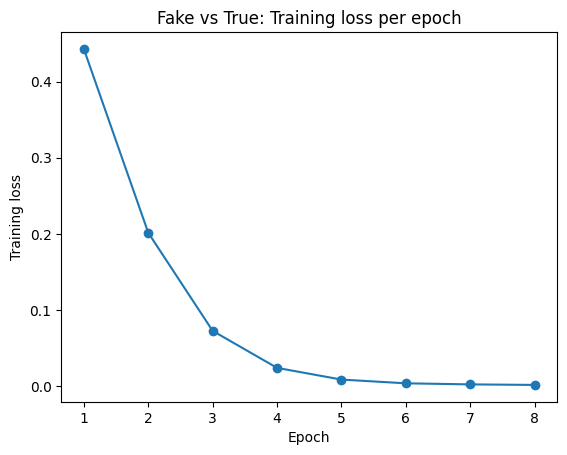

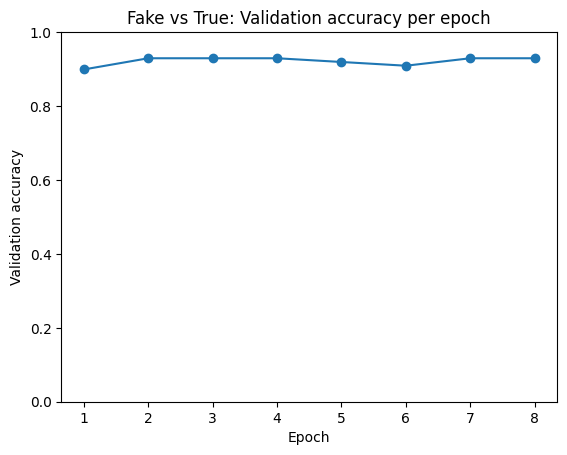

In [37]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Fake vs True: Training loss per epoch")
plt.show()

plt.figure()
plt.plot(epochs, val_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Fake vs True: Validation accuracy per epoch")
plt.ylim(0, 1)
plt.show()

In [38]:
import simple_bert_fake_reviews as sbr
from sklearn.metrics import confusion_matrix
import numpy as np

y_true, y_prob = sbr.get_predictions_and_probs(model, val_loader, device)

len(y_true), len(y_prob)

(99, 99)

In [39]:
threshold = 0.5  # You can play with this value
y_pred = [1 if p >= threshold else 0 for p in y_prob]

In [40]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[18,  6],
       [ 1, 74]])

In [41]:
!pip install seaborn

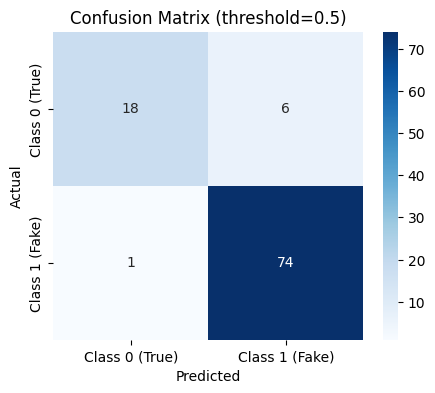

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Class 0 (True)", "Class 1 (Fake)"],
    yticklabels=["Class 0 (True)", "Class 1 (Fake)"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (threshold={threshold})")
plt.show()

In [43]:
import ipywidgets as widgets
from ipywidgets import interact

@interact(threshold=widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05))
def plot_confusion(threshold=0.5):
    y_pred = [1 if p >= threshold else 0 for p in y_prob]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (threshold={threshold:.2f})")
    plt.show()

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…

# 8. Save model

In [44]:
sbr.save_model_and_tokenizer(model, tokenizer, "fake_true_model")
"Model saved!"

'Model saved!'

# 9. Load model again

In [45]:
loaded_model, loaded_tokenizer = sbr.load_model_and_tokenizer("fake_true_model")
loaded_model.to(device)
"Model loaded!"

'Model loaded!'

# 10. Perform predictions

In [46]:
test_reviews = [
    "This product is wonderful, I highly recommend it to everyone.",
    "Worst purchase ever, completely useless.",
    "The item is just okay, but the reviews sound exaggerated.",
]

preds = sbr.predict_fake_true(test_reviews, loaded_model, loaded_tokenizer, device)

for text, label, conf in preds:
    print("Text:      ", text)
    print("Predicted: ", label)      # 'true' or 'fake'
    print("Confidence:", round(conf, 3))
    print("-" * 50)

Text:       This product is wonderful, I highly recommend it to everyone.
Predicted:  true
Confidence: 0.891
--------------------------------------------------
Text:       Worst purchase ever, completely useless.
Predicted:  true
Confidence: 0.989
--------------------------------------------------
Text:       The item is just okay, but the reviews sound exaggerated.
Predicted:  true
Confidence: 0.998
--------------------------------------------------


# 11. BERT vs DistilBERT comparison

## 11.1  Switch to DistilBERT

In [47]:
# Now we try DistilBERT
sbr.MODEL_NAME = "distilbert-base-uncased"

# Optionally change hyperparameters for this model
sbr.LEARNING_RATE = 3e-5
sbr.BATCH_SIZE = 16
sbr.MAX_LEN = 128

print("Now testing model:", sbr.MODEL_NAME)

Now testing model: distilbert-base-uncased


## 11.2 New DataLoaders (DistilBERT tokenizer)

In [48]:

train_loader_distil, test_loader_distil, tokenizer_distil = sbr.create_dataloaders_from_arrays(
    train_texts,
    train_labels,
    val_texts,
    val_labels,
)

## 11.3 Train DistilBERT

In [49]:
model_distil, optimizer_distil = sbr.create_model_and_optimizer()
model_distil.to(device)

NUM_EPOCHS_DISTIL = 8

train_losses_distil = []
accuracies_distil = []

for epoch in range(NUM_EPOCHS_DISTIL):
    print(f"\n[DistilBERT] Epoch {epoch+1}/{NUM_EPOCHS_DISTIL}")
    loss = sbr.train_one_epoch(model_distil, train_loader_distil, optimizer_distil, device)
    acc = sbr.evaluate_accuracy(model_distil, test_loader_distil, device)

    train_losses_distil.append(loss)
    accuracies_distil.append(acc)

    print(f"Loss: {loss:.4f}  Accuracy: {acc:.4f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[DistilBERT] Epoch 1/8


Training:   0%|          | 0/29 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Loss: 0.4573  Accuracy: 0.9091

[DistilBERT] Epoch 2/8


...

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Loss: 0.0288  Accuracy: 0.9394

[DistilBERT] Epoch 8/8


Training:   0%|          | 0/29 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

Loss: 0.0059  Accuracy: 0.8990


## 11.4 Compare curves

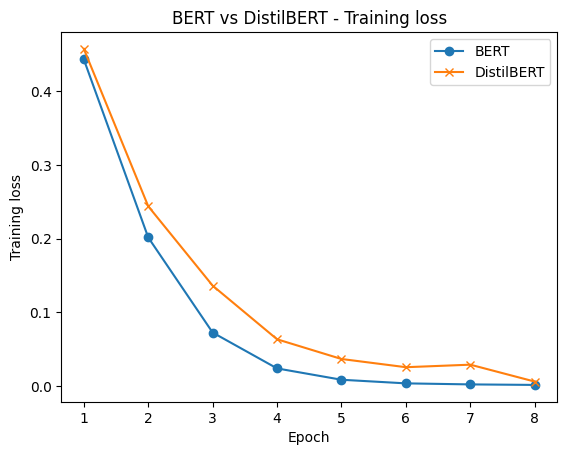

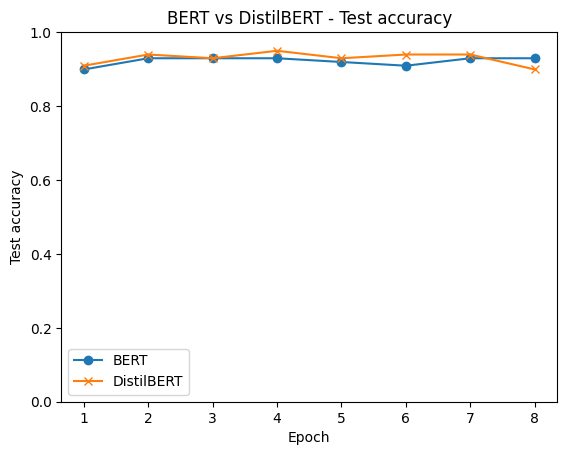

In [51]:
import matplotlib.pyplot as plt

epochs_bert = range(1, len(train_losses) + 1)
epochs_distil = range(1, len(train_losses_distil) + 1)

# Loss comparison
plt.figure()
plt.plot(epochs_bert, train_losses, marker="o", label="BERT")
plt.plot(epochs_distil, train_losses_distil, marker="x", label="DistilBERT")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("BERT vs DistilBERT - Training loss")
plt.legend()
plt.show()

# Accuracy comparison
plt.figure()
plt.plot(epochs_bert, val_accuracies, marker="o", label="BERT")
plt.plot(epochs_distil, accuracies_distil, marker="x", label="DistilBERT")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("BERT vs DistilBERT - Test accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()